<a href="https://colab.research.google.com/github/Asaf-Greenfield-2/ML4P_Asaf_3/blob/main/Final_Project_ML4P_Asaf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pysr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 10.3 MB/s eta 0:00:00


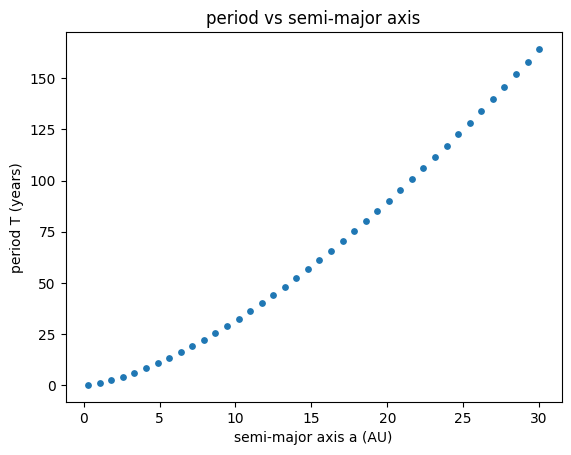

T^2 / a^3 (should be ~1): [1. 1. 1. 1. 1.]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# kepler's third law: T^2 = a^3 (in units where the constant is 1)
# generate orbits with different semi-major axes, get their periods

# semi-major axes (AU)
a = np.linspace(0.3, 30, 40)

# true period from kepler, T = a^1.5
T = a**1.5

# look at it
plt.scatter(a, T, s=15)
plt.xlabel("semi-major axis a (AU)")
plt.ylabel("period T (years)")
plt.title("period vs semi-major axis")
plt.show()

# check: T^2 / a^3 should be ~1 everywhere
print("T^2 / a^3 (should be ~1):", (T**2 / a**3)[:5])

In [ ]:
from pysr import PySRRegressor

# X is the input (semi-major axis), y is what we want it to predict (period)
X = a.reshape(-1, 1)
y = T

model = PySRRegressor(
    niterations=40,
    binary_operators=["+", "*", "/", "-"],
    unary_operators=["sqrt", "square"],   # need these so it can build a^1.5 = a*sqrt(a)
    maxsize=10,                            # keep equations short
)
model.fit(X, y)

# show the equations it found, simplest to most complex
print(model)

[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/pysr/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliacall/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] WARNING: You have Julia 1.12.6 installed but 1.10.3 - 1.11 is required.
[juliapkg]   It is recommended that you upgrade Julia or install JuliaUp.
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] WARNING: About to install Julia 1.11.9 to /root/.julia/environments/pyjuliapkg/pyjuliapkg/install.
[juliapkg]   If you use juliapkg in more than one environment, you are likely to
[juliapkg]   have Julia installed in multiple locations. It is recommended to
[juliapkg]   install JuliaUp (https://github.com/JuliaLang/juliaup) or Julia
[juliapkg]   (https://julialang.org/downloads) yourself.
[juliapkg] Downloading Julia

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 1.450e+05
Progress: 854 / 1240 total iterations (68.871%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.528e+03  0.000e+00  y = 66.8
3           1.426e+02  1.438e+00  y = x₀ * 4.7241
4           1.401e-11  2.995e+01  y = x₀ * sqrt(x₀)
6           1.385e-11  5.720e-03  y = sqrt(x₀) * (x₀ - 1.1921e-07)
8           7.623e-12  2.985e-01  y = (x₀ + (x₀ * sqrt(x₀))) - x₀
10          7.441e-12  1.205e-02  y = ((sqrt(x₀) * (x₀ + -2.7757e-07)) + x₀) - x₀
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.
──────────────────────────────────────────────────

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	   pick      score                                       equation  \
	0         0.000000                                       66.80047   
	1         1.437650                                 x0 * 4.7240944   
	2        29.951199                                  x0 * sqrt(x0)   
	3         0.005720                 sqrt(x0) * (x0 - 1.1920929e-7)   
	4  >>>>   0.298478                    (x0 + (x0 * sqrt(x0))) - x0   
	5         0.012052  ((sqrt(x0) * (x0 + -2.7757233e-7)) + x0) - x0   
	
	           loss  complexity  
	0  2.527548e+03           1  
	1  1.425518e+02           3  
	2  1.400657e-11           4  
	3  1.384726e-11           6  
	4  7.622703e-12           8  
	5  7.441159e-12          10  
]
  - outputs/20260609_114603_lBb6Hq/hall_of_fame.csv


In [ ]:
# add noise to the periods and see when pysr stops finding a^1.5
# sweep a few noise levels, refit each, print what it lands on

noise_levels = [0.0, 0.01, 0.05, 0.10, 0.12, 0.15, .16,.17,.18,0.20,.21,.22,.23,.24,.25,.26,.27,.28]   # fractional noise on T

rng = np.random.default_rng(17)

for noise in noise_levels:
    # corrupt T with gaussian noise proportional to its value
    T_noisy = T * (1 + noise * rng.standard_normal(len(T)))

    m = PySRRegressor(
        niterations=20,
        binary_operators=["+", "*", "/", "-"],
        unary_operators=["sqrt", "square"],
        maxsize=10,
        verbosity=0,
        progress=False,
    )
    m.fit(a.reshape(-1, 1), T_noisy)

    print(f"noise = {noise:.2f}  ->  {m.sympy()}")

noise = 0.00  ->  x0**(3/2)
noise = 0.01  ->  x0**(3/2)
noise = 0.05  ->  x0**(3/2)
noise = 0.10  ->  x0**(3/2)
noise = 0.12  ->  x0**(3/2)
noise = 0.15  ->  x0**(3/2)
noise = 0.16  ->  x0**(3/2)
noise = 0.17  ->  x0*4.6031227
noise = 0.18  ->  x0**(3/2)
noise = 0.20  ->  x0**(3/2)
noise = 0.21  ->  0.215030321373504*x0**2
noise = 0.22  ->  x0**(3/2)
noise = 0.23  ->  0.197840510389876*x0**2
noise = 0.24  ->  0.21017458704192*x0**2
noise = 0.25  ->  x0*4.482256
noise = 0.26  ->  x0**(3/2)
noise = 0.27  ->  x0/0.21371952
noise = 0.28  ->  0.208766976555063*x0**2


T^2 / a^3 (should be ~1): [1. 1. 1. 1. 1.]


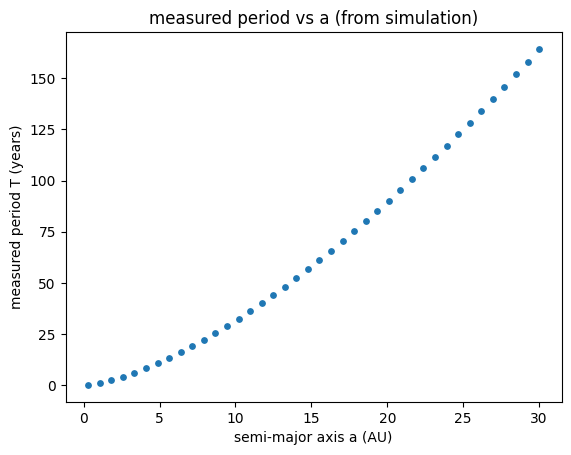

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# instead of assuming T = a^1.5, actually simulate orbits under newton's law
# F = -GM/r^2 and measure the period from the trajectory

GM = 4 * np.pi**2   # units where a=1 AU circular orbit has T=1 yr

# newton's gravity as a system of ODEs: state = [x, y, vx, vy]
def gravity(t, s):
    x, y, vx, vy = s
    r = np.sqrt(x**2 + y**2)
    ax = -GM * x / r**3
    ay = -GM * y / r**3
    return [vx, vy, ax, ay]

# measure the period of an orbit with given semi-major axis a
def measure_period(a):
    # circular orbit: start on x-axis, circular speed sqrt(GM/a)
    v = np.sqrt(GM / a)
    s0 = [a, 0, 0, v]

    def cross(t, s): return s[1]
    cross.direction = 1   # y going upward through 0

    sol = solve_ivp(gravity, [0, 200], s0, events=cross,
                    rtol=1e-9, atol=1e-9, max_step=0.01)

    # skip the crossing at t~0 (we start on the x-axis), take the next one
    times = sol.t_events[0]
    times = times[times > 1e-6]
    return times[0]

# sweep semi-major axes and measure each period
a = np.linspace(0.3, 30, 40)
T = np.array([measure_period(ai) for ai in a])

# check against kepler: T^2/a^3 should be ~1
print("T^2 / a^3 (should be ~1):", (T**2 / a**3)[:5])

plt.scatter(a, T, s=15)
plt.xlabel("semi-major axis a (AU)")
plt.ylabel("measured period T (years)")
plt.title("measured period vs a (from simulation)")
plt.show()

In [ ]:
from pysr import PySRRegressor

X = a.reshape(-1, 1)
y = T

model = PySRRegressor(
    niterations=40,
    binary_operators=["+", "*", "/", "-"],
    unary_operators=["sqrt", "square"],
    maxsize=10,
)
model.fit(X, y)
print(model)

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.670e+05
Progress: 1028 / 1240 total iterations (82.903%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.528e+03  0.000e+00  y = 66.792
3           1.426e+02  1.438e+00  y = x₀ * 4.7242
4           1.401e-11  2.995e+01  y = x₀ * sqrt(x₀)
6           1.390e-11  3.806e-03  y = sqrt(x₀) * (x₀ - 2.4476e-07)
8           7.623e-12  3.004e-01  y = (x₀ + (sqrt(x₀) * x₀)) - x₀
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.


[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.528e+03  0.000e+00  y = 66.792
3           1.426e+02  1.438e+00  y = x₀ * 4.7242
4           1.401e-11  2.995e+01  y = x₀ * sqrt(x₀)
6           1.390e-11  3.806e-03  y = sqrt(x₀) * (x₀ - 2.4476e-07)
8           7.623e-12  3.004e-01  y = (x₀ + (sqrt(x₀) * x₀)) - x₀
───────────────────────────────────────────────────────────────────────────────────────────────────
PySRRegressor.equations_ = [
	   pick      score                        equation          loss  complexity
	0         0.000000                        66.79248  2.527548e+03           1
	1         1.437650                   x0 * 4.724155  1.425518e+02           3
	2        29.951199                   x0 * sqrt(x0)  1.400657e-11           4
	3         0.003806  sqrt(x0) * (x0 - 2.4476054e-7)  1.390035e-11           6
	4  >>>>   0.300391     (x0 + (sqrt(x0) * x0)) - x0  7.622

noise = 0.00  ->  recovered Kepler in 10/10 seeds
noise = 0.05  ->  recovered Kepler in 10/10 seeds
noise = 0.10  ->  recovered Kepler in 10/10 seeds
noise = 0.12  ->  recovered Kepler in 10/10 seeds
noise = 0.15  ->  recovered Kepler in 8/10 seeds
noise = 0.20  ->  recovered Kepler in 4/10 seeds
noise = 0.30  ->  recovered Kepler in 0/10 seeds


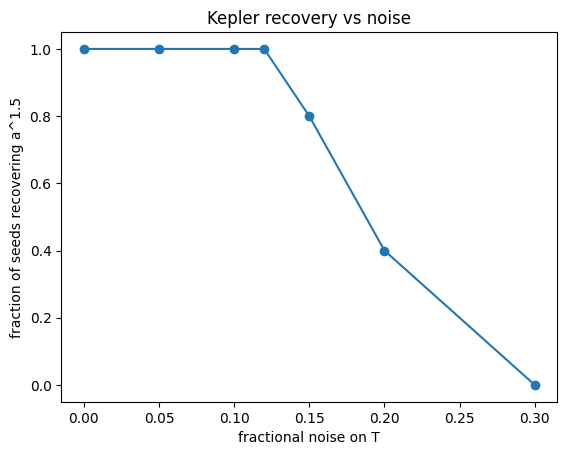

In [ ]:
import numpy as np

noise_levels = [0.0, 0.05, 0.10, 0.12, 0.15, 0.20, 0.30]
n_seeds = 10

# robust check: fit a power law to pysr's predictions and see if exponent ~1.5
def found_kepler(model, a):
    pred = model.predict(a.reshape(-1, 1))
    # guard against nonpositive predictions before logging
    if np.any(pred <= 0):
        return False
    # log(T) = log(C) + p*log(a); slope p should be ~1.5
    p = np.polyfit(np.log(a), np.log(pred), 1)[0]
    return abs(p - 1.5) < 0.1

recovery = []
for noise in noise_levels:
    hits = 0
    for seed in range(n_seeds):
        rng = np.random.default_rng(seed)
        T_noisy = T * (1 + noise * rng.standard_normal(len(T)))
        m = PySRRegressor(
            niterations=15,
            binary_operators=["+", "*", "/", "-"],
            unary_operators=["sqrt", "square"],
            maxsize=10,
            verbosity=0, progress=False,
        )
        m.fit(a.reshape(-1, 1), T_noisy)
        hits += found_kepler(m, a)
    recovery.append(hits / n_seeds)
    print(f"noise = {noise:.2f}  ->  recovered Kepler in {hits}/{n_seeds} seeds")

plt.plot(noise_levels, recovery, 'o-')
plt.xlabel("fractional noise on T")
plt.ylabel("fraction of seeds recovering a^1.5")
plt.title("Kepler recovery vs noise")
plt.ylim(-0.05, 1.05)
plt.show()

In [ ]:
def measure_period_M(a, GM_val):
    v = np.sqrt(GM_val / a)
    s0 = [a, 0, 0, v]
    def grav(t, s):
        x, y, vx, vy = s
        r = np.sqrt(x**2 + y**2)
        return [vx, vy, -GM_val*x/r**3, -GM_val*y/r**3]
    def cross(t, s): return s[1]
    cross.direction = 1
    sol = solve_ivp(grav, [0, 500], s0, events=cross,
                    rtol=1e-7, atol=1e-7, max_step=0.5)   # looser still
    times = sol.t_events[0]
    return times[times > 1e-6][0]

a_vals = np.linspace(0.5, 8, 8)
M_vals = np.linspace(1.0, 4, 8)

A, M, T_mv = [], [], []
total = len(a_vals) * len(M_vals)
done = 0
for ai in a_vals:
    for Mi in M_vals:
        A.append(ai); M.append(Mi)
        T_mv.append(measure_period_M(ai, 4*np.pi**2 * Mi))
        done += 1
        print(f"{done}/{total} orbits done", flush=True)   # plain print + flush
A, M, T_mv = np.array(A), np.array(M), np.array(T_mv)
print("done simulating")
print("T^2 * M / a^3 (should be ~1):", (T_mv**2 * M / A**3)[:5])

X_mv = np.column_stack([A, M])
m_mv = PySRRegressor(
    niterations=60,
    binary_operators=["+", "*", "/", "-"],
    unary_operators=["sqrt", "square"],
    maxsize=12,
    verbosity=0, progress=False,
)
m_mv.fit(X_mv, T_mv)
print(m_mv)

1/64 orbits done
2/64 orbits done
3/64 orbits done
4/64 orbits done
5/64 orbits done
6/64 orbits done
7/64 orbits done
8/64 orbits done
9/64 orbits done
10/64 orbits done
11/64 orbits done
12/64 orbits done
13/64 orbits done
14/64 orbits done
15/64 orbits done
16/64 orbits done
17/64 orbits done
18/64 orbits done
19/64 orbits done
20/64 orbits done
21/64 orbits done
22/64 orbits done
23/64 orbits done
24/64 orbits done
25/64 orbits done
26/64 orbits done
27/64 orbits done
28/64 orbits done
29/64 orbits done
30/64 orbits done
31/64 orbits done
32/64 orbits done
33/64 orbits done
34/64 orbits done
35/64 orbits done
36/64 orbits done
37/64 orbits done
38/64 orbits done
39/64 orbits done
40/64 orbits done
41/64 orbits done
42/64 orbits done
43/64 orbits done
44/64 orbits done
45/64 orbits done
46/64 orbits done
47/64 orbits done
48/64 orbits done
49/64 orbits done
50/64 orbits done
51/64 orbits done
52/64 orbits done
53/64 orbits done
54/64 orbits done
55/64 orbits done
56/64 orbits done
5

In [ ]:
# modified gravity: F ∝ 1/r^n with n slightly off from 2. does pysr notice?
# under 1/r^n, near-circular period scales like a^((n+1)/2)
# so n=2.1 -> exponent 1.55, a 3% deviation from kepler's 1.5

def measure_period_n(a, n):
    GM_val = 4*np.pi**2
    v = np.sqrt(GM_val / a**(n-1))      # circular speed for force ∝ 1/r^n
    s0 = [a, 0, 0, v]
    def grav(t, s):
        x, y, vx, vy = s
        r = np.sqrt(x**2 + y**2)
        f = -GM_val / r**(n+1)           # f*x, f*y give the acceleration components
        return [vx, vy, f*x, f*y]
    def cross(t, s): return s[1]
    cross.direction = 1
    sol = solve_ivp(grav, [0, 500], s0, events=cross,
                    rtol=1e-7, atol=1e-7, max_step=0.5)
    times = sol.t_events[0]
    return times[times > 1e-6][0]

n = 2.1
a_dev = np.linspace(0.3, 30, 40)
T_dev = []
for i, ai in enumerate(a_dev):
    T_dev.append(measure_period_n(ai, n))
    print(f"{i+1}/{len(a_dev)} orbits done", flush=True)
T_dev = np.array(T_dev)

# ground truth: what exponent is actually in the data?
p_true = (n + 1) / 2
p_data = np.polyfit(np.log(a_dev), np.log(T_dev), 1)[0]
print(f"\nmodified force 1/r^{n}: expected exponent {p_true}, measured log-log slope {p_data:.4f}")

# what does pysr say?
m_dev = PySRRegressor(
    niterations=40,
    binary_operators=["+", "*", "/", "-"],
    unary_operators=["sqrt", "square"],
    maxsize=10,
    verbosity=0, progress=False,
)
m_dev.fit(a_dev.reshape(-1, 1), T_dev)
print(m_dev)

1/40 orbits done
2/40 orbits done
3/40 orbits done
4/40 orbits done
5/40 orbits done
6/40 orbits done
7/40 orbits done
8/40 orbits done
9/40 orbits done
10/40 orbits done
11/40 orbits done
12/40 orbits done
13/40 orbits done
14/40 orbits done
15/40 orbits done
16/40 orbits done
17/40 orbits done
18/40 orbits done
19/40 orbits done
20/40 orbits done
21/40 orbits done
22/40 orbits done
23/40 orbits done
24/40 orbits done
25/40 orbits done
26/40 orbits done
27/40 orbits done
28/40 orbits done
29/40 orbits done
30/40 orbits done
31/40 orbits done
32/40 orbits done
33/40 orbits done
34/40 orbits done
35/40 orbits done
36/40 orbits done
37/40 orbits done
38/40 orbits done
39/40 orbits done
40/40 orbits done

modified force 1/r^2.1: expected exponent 1.55, measured log-log slope 1.5500
PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                           77.67629   
	1        1.369424                 

In [ ]:
# trying to FIX the deviation failure: give pysr a power operator so it CAN express a^1.55
# (last time it only had sqrt/square, so it couldn't make a non-half-integer power)

# regenerate the modified-force data (1/r^2.1) in case it's not in memory
def measure_period_n(a, n):
    GM_val = 4*np.pi**2
    v = np.sqrt(GM_val / a**(n-1))      # circular speed for force ∝ 1/r^n
    s0 = [a, 0, 0, v]
    def grav(t, s):
        x, y, vx, vy = s
        r = np.sqrt(x**2 + y**2)
        f = -GM_val / r**(n+1)
        return [vx, vy, f*x, f*y]
    def cross(t, s): return s[1]
    cross.direction = 1
    sol = solve_ivp(grav, [0, 500], s0, events=cross,
                    rtol=1e-7, atol=1e-7, max_step=0.5)
    times = sol.t_events[0]
    return times[times > 1e-6][0]

n = 2.1
a_dev = np.linspace(0.3, 30, 40)
T_dev = []
for i, ai in enumerate(a_dev):
    T_dev.append(measure_period_n(ai, n))
    print(f"{i+1}/{len(a_dev)} orbits done", flush=True)
T_dev = np.array(T_dev)

# ground truth exponent in the data
p_data = np.polyfit(np.log(a_dev), np.log(T_dev), 1)[0]
print(f"\ntrue exponent in data (log-log slope): {p_data:.4f}")

# pysr WITH a power operator and no sqrt/square - forced to find the real exponent
m_dev2 = PySRRegressor(
    niterations=60,
    binary_operators=["+", "*", "/", "-", "^"],   # ^ = raise to a (learnable) power
    unary_operators=[],                            # no sqrt/square, so it can't cheat with 1.5
    maxsize=10,
    verbosity=0, progress=False,
)
m_dev2.fit(a_dev.reshape(-1, 1), T_dev)
print(m_dev2)

1/40 orbits done
2/40 orbits done
3/40 orbits done
4/40 orbits done
5/40 orbits done
6/40 orbits done
7/40 orbits done
8/40 orbits done
9/40 orbits done
10/40 orbits done
11/40 orbits done
12/40 orbits done
13/40 orbits done
14/40 orbits done
15/40 orbits done
16/40 orbits done
17/40 orbits done
18/40 orbits done
19/40 orbits done
20/40 orbits done
21/40 orbits done
22/40 orbits done
23/40 orbits done
24/40 orbits done
25/40 orbits done
26/40 orbits done
27/40 orbits done
28/40 orbits done
29/40 orbits done
30/40 orbits done
31/40 orbits done
32/40 orbits done
33/40 orbits done
34/40 orbits done
35/40 orbits done
36/40 orbits done
37/40 orbits done
38/40 orbits done
39/40 orbits done
40/40 orbits done

true exponent in data (log-log slope): 1.5500


/usr/local/lib/python3.12/dist-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(


PySRRegressor.equations_ = [
	   pick      score                      equation          loss  complexity
	0         0.000000                     77.685005  3.559795e+03           1
	1  >>>>  13.784028                x0 ^ 1.5500002  3.791148e-09           3
	2         0.003510  ((x0 ^ 1.5500002) + x0) - x0  3.738286e-09           7
]


In [ ]:
# EXPERIMENT: can pysr discover a conserved quantity from raw trajectory data?
# i give it (x, y, vx, vy) and ask it to find energy E = 0.5*v^2 - GM/r
# trick: use several different orbits so it can't just output a constant

GM = 4*np.pi**2

def trajectory(r0, v_frac, n_pts=200):
    # start at (r0, 0), give it some velocity in y; v_frac sets how elliptical
    v_circ = np.sqrt(GM / r0)
    s0 = [r0, 0.0, 0.0, v_frac * v_circ]
    def grav(t, s):
        x, y, vx, vy = s
        r = np.sqrt(x**2 + y**2)
        return [vx, vy, -GM*x/r**3, -GM*y/r**3]
    ts = np.linspace(0, 5, n_pts)
    sol = solve_ivp(grav, [0, 5], s0, t_eval=ts, rtol=1e-9, atol=1e-9)
    return sol.y   # shape (4, n_pts): x, y, vx, vy

# build a dataset from several different orbits (different shapes/energies)
states, energies = [], []
for r0, vf in [(1.0, 0.7), (1.0, 0.9), (1.5, 0.8), (2.0, 1.0), (1.2, 1.1)]:
    x, y, vx, vy = trajectory(r0, vf)
    r = np.sqrt(x**2 + y**2)
    v2 = vx**2 + vy**2
    E = 0.5*v2 - GM/r              # the true energy (what we hope it finds)
    states.append(np.column_stack([x, y, vx, vy]))
    energies.append(E)

X_cons = np.vstack(states)         # columns: x0=x, x1=y, x2=vx, x3=vy
y_cons = np.concatenate(energies)

# sanity: energy should be ~constant within each orbit (variance tiny per trajectory)
for i, E in enumerate(energies):
    print(f"orbit {i}: E mean {E.mean():.3f}, std {E.std():.2e}")

# pysr: find a function of (x,y,vx,vy) that equals the energy
m_cons = PySRRegressor(
    niterations=80,
    binary_operators=["+", "*", "/", "-"],
    unary_operators=["square", "sqrt"],
    maxsize=15,
    verbosity=0, progress=False,
)
m_cons.fit(X_cons, y_cons)
print(m_cons)

orbit 0: E mean -29.806, std 9.92e-08
orbit 1: E mean -23.490, std 1.99e-07
orbit 2: E mean -17.897, std 4.83e-08
orbit 3: E mean -9.870, std 1.78e-08
orbit 4: E mean -12.995, std 3.89e-08
PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                         -18.812323   
	1         0.033772                                      -18.6771 - x0   
	2         0.090583                             square(x1) + -19.63404   
	3         0.124999                    square(square(x1)) + -20.505995   
	4         0.196700              -54.026943 / (square(x1) + 2.2739542)   
	5         0.297274       square(square(x1) + square(x0)) + -24.090786   
	6         0.412006  -63.028713 / ((square(x1) + square(x0)) + 1.89...   
	7         0.653377  -18.84407 / sqrt(square(x1) + square(x0 + -0.2...   
	8         0.104487  x0 + (-18.96123 / sqrt(square(x0 + -0.31084198...   
	9         0.436435  (((x0 * 3.1065588) * 

In [ ]:
# EXPERIMENT 1b: can pysr find angular momentum L = x*vy - y*vx from raw state?
# (energy failed - it needs a 1/r term. L needs no 1/r, so this isolates *why* energy failed.)
# reuse X_cons from the energy cell: columns are x0=x, x1=y, x2=vx, x3=vy

x, y, vx, vy = X_cons[:,0], X_cons[:,1], X_cons[:,2], X_cons[:,3]
L_true = x*vy - y*vx

# CHECK 1: is L actually conserved within each orbit? (each orbit was 200 points)
# and CHECK 2: are the per-orbit L values different from each other?
# (if they're all the same, pysr could cheat with a constant - so we need them spread out)
n_pts = 200
n_orbits = len(L_true) // n_pts
print("per-orbit angular momentum:")
for i in range(n_orbits):
    seg = L_true[i*n_pts:(i+1)*n_pts]
    print(f"  orbit {i}: L mean {seg.mean():.4f}, std {seg.std():.2e}")
print(f"\nspread of L across orbits (std of means): {np.std([L_true[i*n_pts:(i+1)*n_pts].mean() for i in range(n_orbits)]):.4f}")

# now let pysr try to find L from (x, y, vx, vy)
m_L = PySRRegressor(
    niterations=80,
    binary_operators=["+", "*", "/", "-"],
    unary_operators=["square"],
    maxsize=12,
    verbosity=0, progress=False,
)
m_L.fit(X_cons, L_true)
print(m_L)

per-orbit angular momentum:
  orbit 0: L mean 4.3982, std 9.43e-09
  orbit 1: L mean 5.6549, std 2.30e-08
  orbit 2: L mean 6.1562, std 9.63e-09
  orbit 3: L mean 8.8858, std 8.00e-09
  orbit 4: L mean 7.5712, std 1.18e-08

spread of L across orbits (std of means): 1.5546
PySRRegressor.equations_ = [
	   pick         score                                           equation  \
	0        0.000000e+00                                            6.53338   
	1        1.750201e-01                              square(x1) + 5.711146   
	2        1.399053e-07                               (x1 * x1) + 5.711163   
	3        3.691030e-02                        square(x1 * x0) + 5.8907866   
	4  >>>>  2.998601e+01                              (x0 * x3) - (x2 * x1)   
	5        1.232456e-02            ((x0 * x3) + -4.4408356e-8) - (x1 * x2)   
	6        1.519275e-01  ((x3 * x0) - ((x2 * x1) + 1.0015789)) + 1.0015789   
	
	           loss  complexity  
	0  2.416723e+00           1  
	1  1.429539e+00  

In [ ]:
# EXPERIMENT 1c: energy failed from raw (x,y,vx,vy). does it work with better features?
# hand pysr r = sqrt(x^2+y^2) and v2 = vx^2+vy^2. then energy = 0.5*v2 - GM/r is simple.
# this tests whether the lever is the REPRESENTATION, not the search.
GM = 4*np.pi**2

x, y, vx, vy = X_cons[:,0], X_cons[:,1], X_cons[:,2], X_cons[:,3]
r  = np.sqrt(x**2 + y**2)
v2 = vx**2 + vy**2
E_true = 0.5*v2 - GM/r

# sanity: confirm E is conserved per orbit and spread across orbits (same checks as before)
n_pts = 200
n_orbits = len(E_true) // n_pts
print("per-orbit energy:")
for i in range(n_orbits):
    seg = E_true[i*n_pts:(i+1)*n_pts]
    print(f"  orbit {i}: E mean {seg.mean():.4f}, std {seg.std():.2e}")
print(f"spread across orbits: {np.std([E_true[i*n_pts:(i+1)*n_pts].mean() for i in range(n_orbits)]):.4f}\n")

# give pysr the engineered features: x0 = r, x1 = v2
X_feat = np.column_stack([r, v2])
m_E = PySRRegressor(
    niterations=80,
    binary_operators=["+", "*", "/", "-"],
    unary_operators=[],
    maxsize=12,
    verbosity=0, progress=False,
)
m_E.fit(X_feat, E_true)
print(m_E)

per-orbit energy:
  orbit 0: E mean -29.8062, std 9.92e-08
  orbit 1: E mean -23.4897, std 1.99e-07
  orbit 2: E mean -17.8969, std 4.83e-08
  orbit 3: E mean -9.8696, std 1.78e-08
  orbit 4: E mean -12.9950, std 3.89e-08
spread across orbits: 7.1749

PySRRegressor.equations_ = [
	   pick      score                                      equation  \
	0         0.000000                                     -18.81166   
	1         0.219773                               -18.254097 / x0   
	2         0.527252                 -34.903103 - (x0 * -12.63905)   
	3  >>>>  14.332028                (x1 * 0.5) + (-39.478416 / x0)   
	4         0.113733  (x1 * -0.49999997) + (x1 + (-39.47842 / x0))   
	
	           loss  complexity  
	0  5.147890e+01           1  
	1  3.316935e+01           3  
	2  1.155505e+01           5  
	3  4.112735e-12           7  
	4  3.276000e-12           9  
]


In [ ]:
#I used Claude and Claude code for the final project